# Order Book Signals on Bond & Equity Calendar Spreads

## 1  Setup & Connection

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')

import polars as pl
import polars.selectors as cs
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from plotnine import *
from plotnine.themes import theme_bw

from src.utils import (
    connect_snowflake,
    create_snowpark_session,
    retrieve_polars_from_snowpark,
    unpack_kwargs,
    unpack_kwargs_for_agg,
    read_table,
    parse_security,
    build_contract_calendar,
    add_roll_window,
    add_microstructure_signals,
    acf_by_security,
    ljungbox_by_security,
    newey_west_maxlags,
)
from snowflake.snowpark import functions as F
from snowflake.snowpark.window import Window
from functools import reduce
import operator

pl.Config.set_tbl_cols(30)
pl.Config.set_tbl_rows(20)
print('polars', pl.__version__)

polars 1.41.2


In [2]:
DB     = 'LISTED_INTERN_PROJECT'
SCHEMA = 'PROJECT_5'
TABLES = ['BINNED_DATA', 'QCODE_MAPPING', 'SECURITY_META']

snowflake_conn = connect_snowflake('../.env')
snowpark = create_snowpark_session('../.env')
print('Connected.')

Connected.


## 2  Data Ingestion

In [3]:
# --- 2  Data Ingestion -------------------------------------------------------------
# Small-scale subset: 2 Phys + 2 Cash qcodes, years 2024-2025.
#
# Futures and calendar spreads of the same product carry DIFFERENT QCODEs in BINNED_DATA,
# so we cannot use a single QCODE filter to capture both instrument types.  Instead:
#   • Futures  — matched by QCODE AND SECURITY NOT LIKE '%/%' (no slash in name).
#   • Spreads  — matched by SECURITY LIKE pattern: {BBG_CODE}%/% {YELLOW_KEY}.
#
# The 2024-2025 date restriction is applied in Section 3 after the contract calendar
# is joined (target_date is delivery-type-aware and not available until that join).
#
# Note: Snowpark's Column.contains() treats its argument as a column identifier, not a
# literal string. All substring checks are expressed as LIKE patterns to avoid this.

BINNED_COLS = [
    'QCODE', 'SECURITY', 'BIN_START_TIME', 'PUBLICATION_DATE',
    'BID_SIZE_START', 'ASK_SIZE_START', 'BID_START', 'ASK_START',
    'VOLUME', 'SIGNED_VOLUME',
]
QCODE_COLS    = ['QCODE', 'BBG_CODE', 'YELLOW_KEY', 'DELIVERY', 'IS_CONVENTION_BUY_NEAR']
SEC_META_COLS = ['SECURITY', 'LAST_TRADE_DATE', 'FIRST_NOTICE_DATE']

qmap     = read_table(snowpark, DB, SCHEMA, 'QCODE_MAPPING', QCODE_COLS)
sec_meta = read_table(snowpark, DB, SCHEMA, 'SECURITY_META', SEC_META_COLS)

# Pick 2 Phys + 2 Cash qcodes for small-scale workshopping.
phys_qcodes = qmap.filter(pl.col('delivery') == 'Phys')['qcode'].unique().to_list()
cash_qcodes = qmap.filter(pl.col('delivery') == 'Cash')['qcode'].unique().to_list()
subset_qcodes = phys_qcodes + cash_qcodes
print(f'Phys qcodes : {phys_qcodes}')
print(f'Cash qcodes : {cash_qcodes}')

# BBG_CODE + YELLOW_KEY for the 4 selected products — used to construct the spread filter.
subset_products = (
    qmap.filter(pl.col('qcode').is_in(subset_qcodes))
    .select('bbg_code', 'yellow_key')
    .unique()
)

fqn_binned = f'{DB}.{SCHEMA}.BINNED_DATA'

# Futures: QCODE in our subset AND SECURITY has no slash (LIKE '%/%' negated).
futures_filter = (
    F.col('QCODE').isin(subset_qcodes) &
    ~F.col('SECURITY').like('%/%')
)

# Spreads: SECURITY matches pattern  {BBG_CODE}.../{...} {YELLOW_KEY}.
# Using Snowflake LIKE: '%' = zero-or-more wildcard characters.

spread_clauses = [
    F.col('SECURITY').like(f'{row["bbg_code"]}%/% {row["yellow_key"]}')
    for row in subset_products.iter_rows(named=True)
]
spread_filter = reduce(operator.or_, spread_clauses)

snow_binned = (
    snowpark.table(fqn_binned)
    .select(*BINNED_COLS)
    .filter(futures_filter | spread_filter)
)
binned = retrieve_polars_from_snowpark(snow_binned)

n_fut = binned.filter(~pl.col('security').str.contains('/')).height
n_spr = binned.filter(pl.col('security').str.contains('/')).height
print(f'binned   : {binned.shape}  (futures: {n_fut:,}  |  spreads: {n_spr:,})')
print(f'qmap     : {qmap.shape}')
print(f'sec_meta : {sec_meta.shape}')
binned.head()

Phys qcodes : ['BF', 'FV', 'GH', 'TU', 'GM', 'IL', 'GX', 'IE']
Cash qcodes : ['AZ', 'OX', 'NN', 'PI', 'TT', 'FX', 'SV', 'DF', 'HN', 'ES']
binned   : (13901208, 10)  (futures: 9,390,042  |  spreads: 4,511,166)
qmap     : (18, 5)
sec_meta : (1106, 3)


qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume
str,str,time,date,f64,f64,f64,f64,i32,i32
"""TT""","""TP2018M/2018U Index""",09:55:00,2018-04-19,1.0,20.0,-4.4,-0.6,0,0
"""NN""","""NQ2016M/2016U Index""",11:45:00,2016-03-18,2.0,1.0,-8.0,-5.05,0,0
"""IL""","""OAT2017U Comdty""",08:50:00,2017-03-28,4.0,6.0,144.65,144.69,0,0
"""TT""","""TP2018U Index""",12:25:00,2018-04-12,4.0,1.0,1713.5,1717.5,0,0
"""OX""","""QC2017J Index""",09:30:00,2017-03-17,29.0,70.0,1556.5,1556.75,720,-9


## 3  Data Preprocessing
Outputs:
- `df_cs` — filtered calendar spreads only.
- `df_combined` — filtered calendar spreads **and** filtered futures.

In [51]:
# --- 3  Merge + parse + calendar + date filter ------------------------------------

# Step 1: merge BINNED_DATA with QCODE_MAPPING on QCODE.
# Spreads pulled via the name-pattern filter may have QCODEs outside subset_qcodes,
# so their bbg_code / yellow_key / delivery / is_convention_buy_near will be null here.
data = binned.join(qmap, on='qcode', how='left')

# Step 2: parse SECURITY -> is_spread, near/far identifiers, meta_key.
data = parse_security(data, col='security')

data.head()

# Steps 3-4: build the per-future roll calendar (target date + own/previous roll windows).
calendar = build_contract_calendar(sec_meta, qmap, roll_days=10)

# Drop qmap's 'delivery' before joining the calendar so the calendar's 'delivery'
# (correctly resolved from BBG_CODE+YELLOW_KEY for every security) is the sole authority.
data = data.drop('delivery')
data = data.join(
    calendar.rename({'security': 'meta_key'}),
    on='meta_key',
    how='left',
)

# Step 5: trading date from PUBLICATION_DATE (BIN_START_TIME is time-only, not a date).
data = data.with_columns(date=pl.col('publication_date').cast(pl.Date))

# Step 6: keep only rows whose near-leg target date is in 2024 or 2025.
# target_date = FIRST_NOTICE_DATE (Phys) or LAST_TRADE_DATE (Cash), already set by the calendar.
data = data.filter(pl.col('publication_date').dt.year().is_in([2024, 2025]))

n_spread = data.filter(pl.col('is_spread')).height
print(f'rows: {data.height:,}  |  spread rows: {n_spread:,}  |  future rows: {data.height - n_spread:,}')
data.select(
    'security', 'is_spread', 'near_identifier', 'far_identifier', 'meta_key',
    'delivery', 'target_date', 'roll_start', 'roll_end', 'prev_roll_start', 'prev_roll_end',
).head()

rows: 2,712,379  |  spread rows: 888,043  |  future rows: 1,824,336


security,is_spread,near_identifier,far_identifier,meta_key,delivery,target_date,roll_start,roll_end,prev_roll_start,prev_roll_end
str,bool,str,str,str,str,date,date,date,date,date
"""GX2024U/2024Z Index""",true,"""GX2024U Index""","""GX2024Z Index""","""GX2024U Index""","""Cash""",2024-09-20,2024-09-06,2024-09-19,2024-06-07,2024-06-20
"""DU2024U/2024Z Comdty""",true,"""DU2024U Comdty""","""DU2024Z Comdty""","""DU2024U Comdty""","""Phys""",2024-09-06,2024-08-23,2024-09-05,2024-05-23,2024-06-05
"""UB2024U Comdty""",false,"""UB2024U Comdty""",null,"""UB2024U Comdty""","""Phys""",2024-09-06,2024-08-23,2024-09-05,2024-05-23,2024-06-05
"""QZ2024M/2024N Index""",true,"""QZ2024M Index""","""QZ2024N Index""","""QZ2024M Index""","""Cash""",2024-06-27,2024-06-13,2024-06-26,2024-05-16,2024-05-29
"""UB2024U/2024Z Comdty""",true,"""UB2024U Comdty""","""UB2024Z Comdty""","""UB2024U Comdty""","""Phys""",2024-09-06,2024-08-23,2024-09-05,2024-05-23,2024-06-05


In [52]:
# --- 3b  Roll-period filtering -----------------------------------------------------


# A bin sits inside a [start, end] window (inclusive). Null bounds (missing metadata) -> False.
def _in_window(start: str, end: str) -> pl.Expr:
    return pl.col('date').is_between(pl.col(start), pl.col(end), closed='both').fill_null(False)

in_own_roll  = _in_window('roll_start', 'roll_end')
in_prev_roll = _in_window('prev_roll_start', 'prev_roll_end')

# Calendar spreads: own (near-leg) roll period only.
df_cs = data.filter(pl.col('is_spread') & in_own_roll)

# Futures: own roll period OR previous contract's roll period.
df_fut = data.filter(~pl.col('is_spread') & (in_own_roll | in_prev_roll))

# Combined: filtered spreads + filtered futures (aligned schema via vertical concat).
df_combined = pl.concat([df_cs, df_fut], how='vertical')

print(f'df_cs       : {df_cs.shape}')
print(f'df_fut      : {df_fut.shape}')
print(f'df_combined : {df_combined.shape}')
df_cs.head()

df_cs       : (203581, 27)
df_fut      : (407469, 27)
df_combined : (611050, 27)


qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume,bbg_code,yellow_key,is_convention_buy_near,is_spread,near_identifier,far_identifier,near_expiry_key,far_expiry_key,meta_key,expiry_key,delivery,target_date,roll_start,roll_end,prev_roll_start,prev_roll_end,date
str,str,time,date,f64,f64,f64,f64,i32,i32,str,str,f64,bool,str,str,i32,i32,str,i32,str,date,date,date,date,date,date
"""SV""","""QZ2024M/2024N Index""",11:20:00,2024-06-25,13893.0,22306.0,1.25,1.3,258,-176,"""QZ""","""Index""",0.0,true,"""QZ2024M Index""","""QZ2024N Index""",202406,202407,"""QZ2024M Index""",202406,"""Cash""",2024-06-27,2024-06-13,2024-06-26,2024-05-16,2024-05-29,2024-06-25
"""GM""","""OE2024U/2024Z Comdty""",10:10:00,2024-08-23,50.0,40.0,-1.3,-1.29,0,0,"""OE""","""Comdty""",1.0,true,"""OE2024U Comdty""","""OE2024Z Comdty""",202409,202412,"""OE2024U Comdty""",202409,"""Phys""",2024-09-06,2024-08-23,2024-09-05,2024-05-23,2024-06-05,2024-08-23
"""TU""","""TU2024Z/2025H Comdty""",08:00:00,2024-11-15,6087.0,1591.0,-0.203125,-0.199219,18,-18,"""TU""","""Comdty""",1.0,true,"""TU2024Z Comdty""","""TU2025H Comdty""",202412,202503,"""TU2024Z Comdty""",202412,"""Phys""",2024-11-29,2024-11-15,2024-11-28,2024-08-16,2024-08-29,2024-11-15
"""IL""","""OAT2024Z/2025H Comdty""",10:25:00,2024-12-05,4830.0,4698.0,0.62,0.63,85,-85,"""OAT""","""Comdty""",1.0,true,"""OAT2024Z Comdty""","""OAT2025H Comdty""",202412,202503,"""OAT2024Z Comdty""",202412,"""Phys""",2024-12-06,2024-11-22,2024-12-05,2024-08-23,2024-09-05,2024-12-05
"""SV""","""QZ2024H/2024J Index""",13:35:00,2024-03-21,3088.0,5700.0,-1.6,-1.55,489,481,"""QZ""","""Index""",0.0,true,"""QZ2024H Index""","""QZ2024J Index""",202403,202404,"""QZ2024H Index""",202403,"""Cash""",2024-03-27,2024-03-13,2024-03-26,2024-02-14,2024-02-27,2024-03-21


In [ ]:
# --- 3c  Roll-Period Seasonality: Volume Dynamics ---------------------------------
# For each BBG_CODE, compute daily volumes for the spread, its near-leg outright,
# and its far-leg outright.  The x-axis is business days before the target date
# (= first notice date for Phys, last trade date for Cash), running from -10 to -1.
# Roll ratio = spread vol / (spread + near + far).
# Each panel shows roll ratio as a line and normalised spread volume as background bars.

# Daily spread volumes
spread_daily = (
    df_cs
    .filter(pl.col('bbg_code').is_not_null() & pl.col('target_date').is_not_null())
    .group_by(['bbg_code', 'date', 'target_date'])
    .agg(vol_spread=pl.col('volume').cast(pl.Float64).sum())
)

# For each (bbg_code, date), the spread tells us which near and far futures are
# active in the same roll event; use that to look up outright volumes in df_combined.
legs_ref = (
    df_cs
    .filter(pl.col('bbg_code').is_not_null() & pl.col('target_date').is_not_null())
    .select(['bbg_code', 'date', 'near_identifier', 'far_identifier', 'target_date'])
    .unique()
)
fut_pool = (
    df_combined.filter(~pl.col('is_spread'))
    .select(['bbg_code', 'date', 'security', 'volume'])
)

near_daily = (
    fut_pool
    .join(
        legs_ref.select(['bbg_code', 'date', 'near_identifier', 'target_date'])
                .rename({'near_identifier': 'security'}),
        on=['bbg_code', 'date', 'security'], how='inner',
    )
    .group_by(['bbg_code', 'date', 'target_date'])
    .agg(vol_near=pl.col('volume').cast(pl.Float64).sum())
)

far_daily = (
    fut_pool
    .join(
        legs_ref.select(['bbg_code', 'date', 'far_identifier', 'target_date'])
                .rename({'far_identifier': 'security'}),
        on=['bbg_code', 'date', 'security'], how='inner',
    )
    .group_by(['bbg_code', 'date', 'target_date'])
    .agg(vol_far=pl.col('volume').cast(pl.Float64).sum())
)

# Combine and compute business-day distance to target
vol_df = (
    spread_daily
    .join(near_daily, on=['bbg_code', 'date', 'target_date'], how='left')
    .join(far_daily,  on=['bbg_code', 'date', 'target_date'], how='left')
    .fill_null(0.0)
)

# np.busday_count(start, end) = business days from start to end (positive).
# Negate so that 1 business day before target = -1.
_dates   = vol_df['date'].to_numpy().astype('datetime64[D]')
_targets = vol_df['target_date'].to_numpy().astype('datetime64[D]')
vol_df   = vol_df.with_columns(
    days_before=pl.Series(-np.busday_count(_dates, _targets))
)

# Roll ratio; aggregate across all roll events per (bbg_code, days_before)
vol_df = (
    vol_df
    .filter(pl.col('days_before').is_between(-10, -1))
    .with_columns(
        roll_ratio=pl.col('vol_spread') /
            (pl.col('vol_spread') + pl.col('vol_near') + pl.col('vol_far'))
    )
)

plot_df = (
    vol_df
    .group_by(['bbg_code', 'days_before'])
    .agg(
        roll_ratio=pl.col('roll_ratio').mean(),
        vol_spread=pl.col('vol_spread').mean(),
    )
    .sort(['bbg_code', 'days_before'])
)

# Normalise spread volume to [0, 1] within each BBG_CODE so bars share the y-axis
# with roll ratio (bar height 1 = max avg daily spread volume for that product).
_vmax = plot_df.group_by('bbg_code').agg(_vmax=pl.col('vol_spread').max())
plot_df = (
    plot_df
    .join(_vmax, on='bbg_code', how='left')
    .with_columns(vol_spread_norm=(pl.col('vol_spread') / pl.col('_vmax')).fill_nan(0.0))
    .drop('_vmax')
    .to_pandas()
)

(
    ggplot(plot_df, aes(x='days_before')) +
    geom_col(aes(y='vol_spread_norm'), fill='steelblue', alpha=0.35, width=0.8) +
    geom_line(aes(y='roll_ratio'), color='#CC0000', size=1.0) +
    geom_point(aes(y='roll_ratio'), color='#CC0000', size=2.0) +
    scale_x_continuous(
        breaks=list(range(-10, 0)),
        limits=(-10.5, -0.5),
    ) +
    scale_y_continuous(
        limits=(0, 1.05),
        breaks=[0, 0.25, 0.5, 0.75, 1.0],
    ) +
    facet_wrap('~bbg_code', nrow=2) +
    labs(
        title='Roll-Period Volume Seasonality by Product',
        subtitle=(
            'Red line = roll ratio (spread / total vol)  |  '
            'Blue bars = normalised spread vol (1 = max avg daily spread vol per product)'
        ),
        x='Business Days Before Target Date',
        y='Roll Ratio  /  Normalised Spread Volume',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(11, 7))
)


## 4  Signal Generation and Exploration

Using the per-bin `*_START` quotes:

| Signal | Definition |
|---|---|
| $P_t$ (`mid_price`) | $(\text{BID\_START} + \text{ASK\_START})/2$ |
| $\Delta P_t$ (`delta_p`) | $P_t - P_{t-1}$ (within session) |
| $OBI_t$ (`obi`) | $\text{BID\_SIZE\_START} - \text{ASK\_SIZE\_START}$ |
| $\Delta L_t^b$ (`delta_lb`) | $Q_t^b-Q_{t-1}^b$ if $P_t^b=P_{t-1}^b$; $\;Q_t^b$ if $P_t^b>P_{t-1}^b$; $\;-Q_{t-1}^b$ if $P_t^b<P_{t-1}^b$ |
| $\Delta L_t^a$ (`delta_la`) | mirror of the bid (an ask *improvement* is a price **decrease**) |
| $OBC_t$ (`ofi`) | $\Delta L_t^b - \Delta L_t^a$  (order-flow imbalance) |
| $STV_t$ (`stv`) | `SIGNED_VOLUME` (dataset); empty bins → 0 |
| $NOI_t$ (`noi`) | $OBC_t - STV_t$ |

A `date` session key is added automatically. Result is saved to **`df_signals`**.

In [76]:
# --- Signal generation (partitioned by SESSION [security, date], ordered by time) ----
df_signals = add_microstructure_signals(df_cs, security_col='security', time_col='bin_start_time')

n_sessions = df_signals.select(['security', 'date']).n_unique()
print(f'df_signals: {df_signals.shape}  ({df_signals["security"].n_unique()} spreads, {n_sessions} sessions)')
df_signals.select(
    'security', 'date', 'bin_start_time', 'mid_price', 'delta_p', 'obi',
    'delta_lb', 'delta_la', 'ofi', 'stv', 'noi', 'days_before'
).describe()

df_signals: (201507, 36)  (208 spreads, 2074 sessions)


statistic,security,date,bin_start_time,mid_price,delta_p,obi,delta_lb,delta_la,ofi,stv,noi,days_before
str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""201507""","""201507""","""201507""",201507.0,201507.0,201507.0,201507.0,201507.0,201507.0,201507.0,201507.0,201507.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,"""2025-01-09 13:47:02.319820""","""12:48:41.037978""",-1.374796,0.005264,2590.718437,-348.551693,922.855077,-1271.40677,-35.882232,-1235.524538,5.488995
"""std""",null,null,null,61.790512,1.15069,466630.043527,113731.309124,102309.3558,175715.280882,6379.900855,175507.260702,2.870565
"""min""","""DU2024H/2024M Comdty""","""2024-01-05""","""07:05:00""",-296.75,-63.0,-8.572536e6,-7.166885e6,-5.647385e6,-1.3020008e7,-730759.0,-1.2936424e7,1.0
"""25%""",null,"""2024-07-05""","""10:45:00""",-1.635,0.0,-568.0,-25.0,-34.0,-40.0,-8.0,-73.0,3.0
"""50%""",null,"""2025-01-03""","""12:45:00""",-0.035,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
"""75%""",null,"""2025-07-04""","""14:45:00""",1.035,0.0,555.0,10.0,8.0,56.0,17.0,65.0,8.0
"""max""","""XU2025Z/2026F Index""","""2025-12-29""","""18:00:00""",305.725,442.0,8.222161e6,6.225243e6,5.853123e6,9.340875e6,449539.0,9.339053e6,10.0


In [77]:
# --- Normalise signals --------------------------------------------------------
# Normalised values overwrite the raw columns so downstream sections (H1, H2, H3)
# use normalised signals automatically.
#
# All five expressions are evaluated against the INPUT state of df_signals in the
# final with_columns call — Polars never sees intermediate results within the same
# call.  This means pl.col('ofi') in the NOI denominator is the PRE-Z-SCORE raw OFI.
#
# fill_nan(None) converts floating-point 0/0 = NaN to null for inactive bins rather
# than propagating NaN into the regression.

ROLL_WIN = 60   # rolling-window length for OFI z-score (bins, within each session)
SESSION  = ['security', 'date']

# 1. Tick size per BBG_CODE: minimum strictly-positive |delta_p|.
tick_sizes = (
    df_signals
    .filter(pl.col('delta_p').abs() > 10e-6)  # filter out zero and near-zero price changes to avoid noise/tick size confusion)
    .group_by('bbg_code')
    .agg(_tick=pl.col('delta_p').abs().min())
)
df_signals = df_signals.join(tick_sizes, on='bbg_code', how='left')

# Pre-compute rolling OFI mean and std within each session.
# df_signals is already sorted by [security, date, bin_start_time].
df_signals = df_signals.with_columns(
    _ofi_mu=pl.col('ofi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _ofi_sd=pl.col('ofi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)

# Apply all five normalisations in a single pass.
_vol = pl.col('volume').cast(pl.Float64)

df_signals = df_signals.with_columns(
    # 1. delta_p in ticks (per-BBG_CODE tick size).
    delta_p=(pl.col('delta_p') / pl.col('_tick')).fill_nan(None),
    # 2. OBI as fraction of total quoted size at the touch.
    obi=(pl.col('obi') / (pl.col('bid_size_start') + pl.col('ask_size_start'))).fill_nan(None),
    # 3. STV as fraction of unsigned volume.
    stv=(pl.col('stv').cast(pl.Float64).abs().sqrt() * pl.col('stv').sign()).fill_nan(None),
    # 4. OFI as rolling z-score within session.
    ofi=((pl.col('ofi') - pl.col('_ofi_mu')) / pl.col('_ofi_sd')).fill_nan(None),
    # 5. NOI normalised by (unsigned volume + raw |OFI|).
    #    pl.col('ofi') below reads the ORIGINAL raw OFI (input state of this with_columns).
    noi=(pl.col('noi').cast(pl.Float64).abs().sqrt() * pl.col('noi').sign()).fill_nan(None),
).drop(['_ofi_mu', '_ofi_sd'])

df_signals = df_signals.with_columns(
    _stv_mu=pl.col('stv').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _stv_sd=pl.col('stv').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _noi_mu=pl.col('noi').rolling_mean(window_size=ROLL_WIN, min_samples=2).over(SESSION),
    _noi_sd=pl.col('noi').rolling_std(window_size=ROLL_WIN, min_samples=2).over(SESSION),
)

df_signals = df_signals.with_columns(
    _stv_sd=pl.when(pl.col('_stv_sd') < 1e-6).then(pl.col('_stv_sd').filter(pl.col('_stv_sd') >= 1e-6).mean()).otherwise(pl.col('_stv_sd')),
    _noi_sd=pl.when(pl.col('_noi_sd') < 1e-6).then(pl.col('_noi_sd').filter(pl.col('_noi_sd') >= 1e-6).mean()).otherwise(pl.col('_noi_sd')),
)

df_signals = df_signals.with_columns(
    stv=((pl.col('stv') - pl.col('_stv_mu')) / pl.col('_stv_sd')),
    noi=((pl.col('noi') - pl.col('_noi_mu')) / pl.col('_noi_sd')),
).drop(['_stv_mu', '_stv_sd', '_noi_mu', '_noi_sd'])

print(f'df_signals (normalised): {df_signals.shape}')
df_signals.select('security', 'date', 'bin_start_time', 'delta_p', 'obi', 'stv', 'ofi', 'noi').describe()

df_signals (normalised): (201507, 37)


statistic,security,date,bin_start_time,delta_p,obi,stv,ofi,noi
str,str,str,str,f64,f64,f64,f64,f64
"""count""","""201507""","""201507""","""201507""",201507.0,201507.0,199433.0,197575.0,199433.0
"""null_count""","""0""","""0""","""0""",0.0,0.0,2074.0,3932.0,2074.0
"""mean""",null,"""2025-01-09 13:47:02.319820""","""12:48:41.037978""",0.002923,-0.003161,-0.000386,0.007553,0.003635
"""std""",null,null,null,3.925065,0.539295,0.975851,0.951701,0.954819
"""min""","""DU2024H/2024M Comdty""","""2024-01-05""","""07:05:00""",-126.0,-0.999984,-7.616867,-7.616867,-7.616867
"""25%""",null,"""2024-07-05""","""10:45:00""",0.0,-0.394366,-0.333333,-0.228955,-0.483138
"""50%""",null,"""2025-01-03""","""12:45:00""",0.0,0.0,0.0,0.006946,0.0
"""75%""",null,"""2025-07-04""","""14:45:00""",0.0,0.386861,0.333333,0.244079,0.491186
"""max""","""XU2025Z/2026F Index""","""2025-12-29""","""18:00:00""",884.0,0.999981,7.616867,7.616867,7.616867


In [55]:
# roll period is when daily volume exceeds 25% of daily max for same security

daily_volume = df_signals.group_by('security', 'date').agg(daily_vol=pl.col('volume').sum())

max_volume = daily_volume.group_by('security').agg(max_daily_vol=pl.col('daily_vol').max())

df_signals = df_signals.join(daily_volume, on=['security', 'date'], how='left')
df_signals = df_signals.join(max_volume, on='security', how='left')
df_signals = df_signals.with_columns(
    is_roll_period=(pl.col('daily_vol') >= 0.25 * pl.col('max_daily_vol'))
).drop(['daily_vol', 'max_daily_vol'])

df_signals = df_signals.filter(pl.col('is_roll_period'))

zero_pct = (df_signals
    .with_columns(is_change_small=(pl.col("delta_p").abs().cast(pl.Int32) <= 2) & (pl.col("delta_p").abs().cast(pl.Int32) != 5))
    .group_by("bbg_code")
    .agg((pl.col("is_change_small").mean() * 100))
    .sort('is_change_small')
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
)

spread_one_tick_pct = (df_signals
    .with_columns(is_one_tick=(pl.col("ask_start") - pl.col("bid_start"))//pl.col("_tick") <= 2)
    .group_by("bbg_code")
    .agg((pl.col("is_one_tick").mean() * 100))
    .sort('is_one_tick')
    .join(
        qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left'
    )
)

daily_volatility = (
    df_signals
    .group_by(['bbg_code', 'date'])
    .agg(daily_volatility=pl.col('delta_p').std())
    .filter(pl.col('daily_volatility') > 0)  # filter out zero-vol days to avoid division issues in tick-to-vol ratio
)

tick_to_volatility_ratio = (
    daily_volatility
    .group_by('bbg_code')
    .agg(tick_to_volatility=(1 / pl.col('daily_volatility')).mean())
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
    .sort('tick_to_volatility')
)

depth_to_trade_ratio = (
    df_signals
    .group_by(['bbg_code', 'date'])
    .agg(
        depth=(pl.col('bid_size_start') + pl.col('ask_size_start')).sum(),
        volume=pl.col('volume').sum()
    )
    .with_columns(depth_to_trade=pl.col('depth') / pl.col('volume'))
    .group_by('bbg_code')
    .agg(avg_depth_to_trade=pl.col('depth_to_trade').mean())
    .join(qmap.select(['bbg_code', 'yellow_key']), on='bbg_code', how='left')
    .sort('avg_depth_to_trade')
)

print(f"Percentage of zeros: {zero_pct}%")
print(f"Percentage of one-tick spreads: {spread_one_tick_pct}%")
print(f"Average tick-to-volatility ratio: {tick_to_volatility_ratio}")
print(f"Average depth-to-trade ratio: {depth_to_trade_ratio}")

Percentage of zeros: shape: (18, 3)
┌──────────┬─────────────────┬────────────┐
│ bbg_code ┆ is_change_small ┆ yellow_key │
│ ---      ┆ ---             ┆ ---        │
│ str      ┆ f64             ┆ str        │
╞══════════╪═════════════════╪════════════╡
│ NQ       ┆ 15.825321       ┆ Index      │
│ ES       ┆ 59.97151        ┆ Index      │
│ QC       ┆ 91.82855        ┆ Index      │
│ XU       ┆ 93.015298       ┆ Index      │
│ GX       ┆ 95.036765       ┆ Index      │
│ TP       ┆ 97.728395       ┆ Index      │
│ XP       ┆ 99.424342       ┆ Index      │
│ VG       ┆ 99.459459       ┆ Index      │
│ OAT      ┆ 99.608866       ┆ Comdty     │
│ IK       ┆ 99.766667       ┆ Comdty     │
│ UB       ┆ 99.788136       ┆ Comdty     │
│ DU       ┆ 99.824664       ┆ Comdty     │
│ QZ       ┆ 99.83428        ┆ Index      │
│ RX       ┆ 99.920551       ┆ Comdty     │
│ TU       ┆ 99.939357       ┆ Comdty     │
│ OE       ┆ 99.943503       ┆ Comdty     │
│ EO       ┆ 99.96732        ┆ Index    

In [ ]:
# Scatter plot relations zero_pct, spread_one_tick_pct, tick_to_volatility_ratio
merged_df = (
    zero_pct
    .join(spread_one_tick_pct, on=["bbg_code", "yellow_key"], how="inner")
    .join(tick_to_volatility_ratio, on=["bbg_code", "yellow_key"], how="inner")
    .join(depth_to_trade_ratio, on=["bbg_code", "yellow_key"], how="inner")
)

# 3. Reshape the data to build a custom scatter plot matrix grid
variables = ["is_change_small", "is_one_tick", "tick_to_volatility", "avg_depth_to_trade"]
pairwise_dfs = []

for x_var in variables:
    for y_var in variables:
        # Create a slice of data for each pair configuration (Row x Column)
        pair_df = merged_df.select([
            pl.col("yellow_key"),
            pl.col(x_var).alias("x_value").rank(),
            pl.col(y_var).alias("y_value").rank(),
        ]).with_columns([
            pl.lit(x_var).alias("x_var"),
            pl.lit(y_var).alias("y_var")
        ])
        pairwise_dfs.append(pair_df)

# Combine all pairs into a single flat table
plot_df = pl.concat(pairwise_dfs)

# 4. Plot using Plotnine (requires converting to a pandas DataFrame)
pdf = plot_df.to_pandas()

(
    ggplot(pdf, aes(x="x_value", y="y_value", color="yellow_key"))
    + geom_point(alpha=0.6, size=1.5)
    # facet_grid creates the matrix layout; scales="free" allows each metric to keep its original range
    + facet_grid("y_var ~ x_var", scales="free")
    # Explicitly map distinct colors to 'Comdty' and 'Index'
    + scale_color_manual(values={"Comdty": "#E69F00", "Index": "#56B4E9"})
    + theme_bw()
    + labs(
        title="Scatter Plot Matrix",
        x="",
        y="",
        color="Yellow Key"
    )
)

In [ ]:
# graph of marginal distribution of delta_p for NQ and OAT
(
    ggplot(df_signals.filter(pl.col("bbg_code").is_in(["OAT"])), aes(x='delta_p')) +
    geom_histogram(binwidth=1, fill='steelblue', color='black', alpha=0.7) +
    facet_wrap('~bbg_code', nrow=1) +
    labs(
        title='Distribution of Normalised Price Changes (delta_p) by Product',
        x='Normalised Price Change (ticks)',
        y='Frequency',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(7, 7))
)

In [ ]:
# graph of marginal distribution of stv and noi for NQ and OAT
(
    ggplot(df_signals.filter(pl.col("bbg_code").is_in(["OAT"])), aes(x='stv')) +
    geom_histogram(binwidth=0.5, fill='steelblue', color='black', alpha=0.7) +
    facet_wrap('~bbg_code', nrow=1) +
    labs(
        title='Distribution of Normalised Signed Trade Volume (STV) by Product',
        x='Normalised Signed Trade Volume',
        y='Frequency',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(7, 7))
)

In [ ]:
(
    ggplot(df_signals.filter(pl.col("bbg_code").is_in(["NQ"])), aes(x='noi')) +
    geom_histogram(binwidth=0.5, fill='steelblue', color='black', alpha=0.7) +
    facet_wrap('~bbg_code', nrow=1) +
    labs(
        title='Distribution of Normalised Net Order Imbalance (NOI) by Product',
        x='Normalised Net Order Imbalance',
        y='Frequency',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(7, 7))
)

In [ ]:
# graph of marginal distribution of obi for NQ and OAT
(
    ggplot(df_signals.filter(pl.col("bbg_code").is_in(["NQ"])), aes(x='obi')) +
    geom_histogram(binwidth=0.05, fill='steelblue', color='black', alpha=0.7) +
    facet_wrap('~bbg_code', nrow=1) +
    labs(
        title='Distribution of Normalised Order Book Imbalance (OBI) by Product',
        x='Normalised Order Book Imbalance',
        y='Frequency',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(7, 7))
)

In [ ]:
# graph of marginal distribution of ofi for NQ and OAT
(
    ggplot(df_signals.filter(pl.col("bbg_code").is_in(["NQ"])), aes(x='ofi')) +
    geom_histogram(binwidth=0.5, fill='steelblue', color='black', alpha=0.7) +
    facet_wrap('~bbg_code', nrow=1) +
    labs(
        title='Distribution of Normalised Order Flow Imbalance (OFI) by Product',
        x='Normalised Order Flow Imbalance',
        y='Frequency',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(7, 7))
)

In [ ]:
# --- 5c  Intraday Signal Profiles: Early / Peak / Late Roll Days ------------------
# For each BBG_CODE, select the calendar spread security with the highest total
# volume over its roll period, then identify three representative days:
#   Peak  = date with maximum daily spread volume
#   Early = first date with volume >= 25% of peak  (1 business day before peak if tied)
#   Late  = last  date with volume >= 25% of peak  (1 business day after  peak if tied)
# Plot delta_p (left axis) and OBI / NOI / STV (right axis, [-1,1]) vs intraday time.
# Layout: 4 rows (BBG_CODE) x 3 columns (Early / Peak / Late) = 12 plots.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Select one security per BBG_CODE: the one with highest total volume
best_sec_df = (
    df_signals
    .filter(pl.col('bbg_code').is_not_null())
    .group_by(['bbg_code', 'security'])
    .agg(total_vol=pl.col('volume').cast(pl.Float64).sum())
    .sort(['bbg_code', 'total_vol'], descending=[False, True])
    .unique(subset=['bbg_code'], keep='first')   # first = highest vol after sort
    .sort('bbg_code')
)
bbg_codes = best_sec_df['bbg_code'].to_list()
sec_map   = dict(zip(best_sec_df['bbg_code'], best_sec_df['security']))

# Phase-date selection helper
def get_phase_dates(sig, bbg, sec):
    # Returns (early_date, peak_date, late_date) as Python date objects
    daily = (
        sig.filter((pl.col('bbg_code') == bbg) & (pl.col('security') == sec))
        .group_by('date')
        .agg(v=pl.col('volume').cast(pl.Float64).sum())
        .sort('date')
    )
    if daily.height == 0:
        return None, None, None

    peak_idx = int(daily['v'].arg_max())
    peak_dt  = daily['date'][peak_idx]
    peak_vol = float(daily['v'][peak_idx])

    above    = daily.filter(pl.col('v') >= 0.25 * peak_vol).sort('date')
    early_dt = above['date'][0]
    late_dt  = above['date'][-1]

    def bd_offset(d, n):
        roll = 'preceding' if n < 0 else 'following'
        return pd.Timestamp(np.busday_offset(np.datetime64(str(d), 'D'), n, roll=roll)).date()

    if early_dt == peak_dt:
        early_dt = bd_offset(peak_dt, -1)
    if late_dt == peak_dt:
        late_dt = bd_offset(peak_dt, +1)

    return early_dt, peak_dt, late_dt

# Build 4-row x 3-column figure
PHASES              = ['Early', 'Peak', 'Late']
C_DP, C_OBI, C_NOI, C_STV = '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'

n_rows = len(bbg_codes)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3.5 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, 3)

for row, bbg in enumerate(bbg_codes):
    sec = sec_map[bbg]
    early_dt, peak_dt, late_dt = get_phase_dates(df_signals, bbg, sec)

    for col, (phase, dt) in enumerate(zip(PHASES, [early_dt, peak_dt, late_dt])):
        ax = axes[row, col]
        ax.set_title(f'{phase} Roll  –  {dt}', fontsize=9)
        ax.tick_params(axis='y', labelcolor=C_DP, labelsize=7)

        # Row label on leftmost panel
        row_lbl = f'{bbg}\n{sec[:28]}\n\ndelta_p (ticks)'
        ax.set_ylabel(row_lbl if col == 0 else 'delta_p (ticks)', fontsize=7.5, color=C_DP)

        if dt is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            continue

        session = (
            df_signals
            .filter(
                (pl.col('bbg_code') == bbg) &
                (pl.col('security') == sec) &
                (pl.col('date') == dt)
            )
            .sort('bin_start_time')
        )

        if session.height == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            continue

        x        = list(range(session.height))
        t_labels = [str(t)[:5] for t in session['bin_start_time'].to_list()]  # HH:MM

        # Left axis: delta_p
        ax.plot(x, session['delta_p'].to_numpy(allow_copy=True),
                color=C_DP, linewidth=1.2, label='delta_p')
        ax.axhline(0, color=C_DP, linewidth=0.3, linestyle='--', alpha=0.5)
        # Centre delta_p y-axis at 0 with integer increments
        _dp_vals = session['delta_p'].drop_nulls().to_numpy(allow_copy=True)
        if len(_dp_vals) > 0:
            _half = max(1, int(np.ceil(np.abs(_dp_vals).max())))
            ax.set_ylim(-_half, _half)
        ax.yaxis.set_major_locator(mticker.MultipleLocator(1))

        # Right axis: OBI, NOI, STV
        ax2 = ax.twinx()
        ax2.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        for sig, color, lbl in [
            # ('obi', C_OBI, 'OBI'),
            ('noi', C_NOI, 'NOI'),
            # ('stv', C_STV, 'STV'),
        ]:
            ax2.plot(x, session[sig].to_numpy(allow_copy=True),
                     color=color, linewidth=0.9, alpha=0.85, label=lbl)
        ax2.axhline(0, color='gray', linewidth=0.4, linestyle='--')
        ax2.set_ylim(-500, 500)
        ax2.set_ylabel('NOI', fontsize=7.5)
        ax2.tick_params(axis='y', labelsize=7)

        # X-axis: show ~5 time labels
        step = max(1, len(x) // 5)
        ax.set_xticks(x[::step])
        ax.set_xticklabels(t_labels[::step], rotation=45, ha='right', fontsize=6.5)

        # Legend once (top-left subplot)
        if row == 0 and col == 0:
            l1, lb1 = ax.get_legend_handles_labels()
            l2, lb2 = ax2.get_legend_handles_labels()
            ax2.legend(l1 + l2, lb1 + lb2, loc='upper right',
                       fontsize=6.5, framealpha=0.75)

fig.suptitle(
    'Intraday Signal Profiles Across Roll Phases  (Early / Peak / Late)',
    fontsize=12, y=1.005,
)
plt.tight_layout()
plt.show()


In [102]:
tick_constrained_bbg =['OE', 'XP', 'DU', 'IK', 'RX', 'QZ', 'FV', 'TU', 'VG', 'UB', 'OAT']


df_signals_tu = df_signals.filter(~pl.col('bbg_code').is_in(tick_constrained_bbg))
df_signals_tc = df_signals.filter(pl.col('bbg_code').is_in(tick_constrained_bbg))

df_signals_tc.describe()

statistic,qcode,security,bin_start_time,publication_date,bid_size_start,ask_size_start,bid_start,ask_start,volume,signed_volume,bbg_code,yellow_key,is_convention_buy_near,is_spread,…,roll_start,roll_end,prev_roll_start,prev_roll_end,date,mid_price,obi,delta_p,delta_lb,delta_la,ofi,stv,noi,days_before,_tick
str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,str,f64,f64,…,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""109688""","""109688""","""109688""","""109688""",109688.0,109688.0,109688.0,109688.0,109688.0,109688.0,"""109688""","""109688""",109688.0,109688.0,…,"""109688""","""109688""","""109688""","""109688""","""109688""",109688.0,109688.0,109688.0,109688.0,109688.0,107997.0,108650.0,108650.0,109688.0,109688.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0,…,"""0""","""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,1691.0,1038.0,1038.0,0.0,0.0
"""mean""",null,null,"""12:49:44.957333""","""2025-01-12 09:31:28.089854""",147802.94199,142986.351087,-1.854241,-1.739288,1957.286248,-87.958236,null,null,0.78995,1.0,…,"""2025-01-05 18:25:24.965356""","""2025-01-18 10:56:57.518780""","""2024-10-19 02:57:35.852964""","""2024-10-31 22:35:33.586171""","""2025-01-12 09:31:28.089854""",-1.796765,0.012353,0.025955,-647.941151,1705.276575,0.001946,-0.00587,0.003147,5.496536,0.045065
"""std""",null,null,null,null,725355.895167,706996.001575,12.930356,12.816227,12285.253993,8628.377431,null,null,0.407346,null,…,null,null,null,null,null,12.8721,0.530208,3.160379,154149.854588,138664.30555,0.971094,0.994679,0.973816,2.872775,0.113258
"""min""","""BF""","""DU2024H/2024M Comdty""","""07:05:00""","""2024-01-16""",1.0,1.0,-58.0,-57.0,0.0,-730759.0,"""DU""","""Comdty""",0.0,1.0,…,"""2024-01-16""","""2024-01-29""","""2023-11-16""","""2023-11-29""","""2024-01-16""",-57.5,-0.999984,-126.0,-7.166885e6,-5.647385e6,-7.616867,-7.616867,-7.616867,1.0,0.001953
"""25%""",null,null,"""10:35:00""","""2024-07-16""",566.0,565.0,-0.570312,-0.546875,0.0,-26.0,null,null,1.0,null,…,"""2024-07-16""","""2024-07-29""","""2024-05-17""","""2024-05-30""","""2024-07-16""",-0.558594,-0.327511,0.0,-100.0,-109.0,-0.227305,-0.348051,-0.501113,3.0,0.005
"""50%""",null,null,"""12:50:00""","""2025-01-14""",7303.0,6868.0,-0.065,-0.05,61.0,0.0,null,null,1.0,null,…,"""2025-01-14""","""2025-01-27""","""2024-11-15""","""2024-11-28""","""2025-01-14""",-0.0625,0.00438,0.0,0.0,0.0,0.00412,0.0,0.0,5.0,0.005
"""75%""",null,null,"""15:00:00""","""2025-07-16""",36734.0,35686.0,0.65,0.72,668.0,31.0,null,null,1.0,null,…,"""2025-07-16""","""2025-07-29""","""2025-05-16""","""2025-05-29""","""2025-07-16""",0.675,0.372959,0.0,65.0,67.0,0.22552,0.316676,0.506277,8.0,0.025
"""max""","""TU""","""XP2025Z/2026H Index""","""18:00:00""","""2025-12-29""",8.302973e6,9.625817e6,56.75,57.0,1.170799e6,449539.0,"""XP""","""Index""",1.0,1.0,…,"""2025-12-16""","""2025-12-29""","""2025-11-13""","""2025-11-26""","""2025-12-29""",56.875,0.999981,884.0,6.225243e6,5.853123e6,7.616867,7.616867,7.616867,10.0,0.5


## 5  Hypothesis H1 — Autocorrelation & Persistence (Research Plan §5.1)

**H1:** both Signed Trade Volume ($STV_t$) and Net Order Inflow ($NOI_t$) exhibit significant,
slowly-decaying positive autocorrelation.

To keep the analysis **strictly intraday**, the ACF and Ljung-Box Q-test are computed
**per session `[SECURITY, DATE]`** (ordered by `BIN_START_TIME`) and then aggregated —
concatenating across day boundaries would inject spurious overnight/weekend lags. For each
$X \in \{STV_t, NOI_t\}$ we report the cross-sectional **mean ACF** out to lag $L=20$ (with the
$\pm 1.96/\sqrt{\bar n}$ white-noise band) and the **Ljung-Box** Q-test, validating H1 if the
null of no serial correlation is rejected at $p < 0.01$.

In [79]:
# --- 6a  Sample ACF up to lag L = 12 (per SESSION [security, date], then averaged) ----
L = 12
SESSION = ['security', 'date']
acf_results = {}

# Mean session length (used for the approximate white-noise band).
avg_n = df_signals_tu.group_by(SESSION).len()['len'].mean()
band = 1.96 / np.sqrt(avg_n)

for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals_tu, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')

acf_table = pl.DataFrame({'lag': list(range(1, L + 1)),
                          'acf_stv': acf_results['stv'],
                          'acf_noi': acf_results['noi'],
                          'acf_obi': acf_results['obi'],
                          'acf_ofi': acf_results['ofi']})
acf_table


=== ACF of STV  (1021 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.1256  
    lag  2: +0.0703  
    lag  3: +0.0465  
    lag  4: +0.0357  
    lag  5: +0.0322  
    lag  6: +0.0221  
    lag  7: +0.0174  
    lag  8: +0.0138  
    lag  9: +0.0086  
    lag 10: +0.0066  
    lag 11: -0.0027  
    lag 12: -0.0042  

=== ACF of NOI  (1032 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: -0.1019  
    lag  2: +0.0174  
    lag  3: +0.0179  
    lag  4: +0.0103  
    lag  5: +0.0122  
    lag  6: +0.0096  
    lag  7: +0.0075  
    lag  8: +0.0038  
    lag  9: -0.0012  
    lag 10: -0.0012  
    lag 11: -0.0062  
    lag 12: -0.0054  

=== ACF of OBI  (1034 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.5221 *
    lag  2: +0.3972 *
    lag  3: +0.3175 *
    lag  4: +0.2606 *
    lag  5: +0.2194 *
    lag  6: +0.1875  
    lag  7: +0.1565  
    lag  8: +0.1280  
    lag  9: +0.1116  
    lag 10

lag,acf_stv,acf_noi,acf_obi,acf_ofi
i64,f64,f64,f64,f64
1,0.125558,-0.101886,0.522126,0.018695
2,0.07029,0.017373,0.397237,0.010117
3,0.046541,0.017921,0.317495,0.008049
4,0.035734,0.01029,0.260635,0.007095
5,0.032154,0.012191,0.219366,0.005467
6,0.022052,0.009559,0.187515,0.002261
7,0.017404,0.007536,0.156488,-0.001708
8,0.013792,0.003796,0.127963,-0.003286
9,0.008564,-0.001159,0.111602,-0.006299


In [70]:
# --- 6b  Ljung-Box Q-test (cumulative through lag 20), per SESSION [security, date] ----
ALPHA = 0.01

for col in ['stv', 'noi', 'obi', 'ofi']:
    lb = ljungbox_by_security(
        df_signals_tu, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', lag=L, min_obs=50,
    )
    n_total = lb.height
    n_reject = lb.filter(pl.col('lb_pvalue') < ALPHA).height
    print(f'\n=== Ljung-Box Q-test on {col.upper()} (lag {L}) ===')
    print(f'    sessions tested       : {n_total}')
    print(f'    reject H0 @ p<{ALPHA}    : {n_reject}/{n_total} ({n_reject / n_total:.1%})')
    print(f'    median Q p-value      : {lb["lb_pvalue"].median():.2e}')
    print(f'    median Q-statistic    : {lb["lb_stat"].median():,.1f}')

# --- H1 verdict --------------------------------------------------------------------
print('\n' + '=' * 60)
print('H1 verdict: significant, slowly-decaying POSITIVE autocorrelation')
print('is confirmed when the mean ACF stays positive above the band across')
print(f'lags and the Ljung-Box null is rejected (p<{ALPHA}) for ~all sessions.')


=== Ljung-Box Q-test on STV (lag 12) ===
    sessions tested       : 1021
    reject H0 @ p<0.01    : 181/1021 (17.7%)
    median Q p-value      : 3.65e-01
    median Q-statistic    : 13.1

=== Ljung-Box Q-test on NOI (lag 12) ===
    sessions tested       : 1032
    reject H0 @ p<0.01    : 136/1032 (13.2%)
    median Q p-value      : 2.91e-01
    median Q-statistic    : 14.2

=== Ljung-Box Q-test on OBI (lag 12) ===
    sessions tested       : 1034
    reject H0 @ p<0.01    : 713/1034 (69.0%)
    median Q p-value      : 2.93e-10
    median Q-statistic    : 70.2

=== Ljung-Box Q-test on OFI (lag 12) ===
    sessions tested       : 1030
    reject H0 @ p<0.01    : 83/1030 (8.1%)
    median Q p-value      : 4.11e-01
    median Q-statistic    : 12.4

H1 verdict: significant, slowly-decaying POSITIVE autocorrelation
is confirmed when the mean ACF stays positive above the band across
lags and the Ljung-Box null is rejected (p<0.01) for ~all sessions.


In [80]:
for col in ['stv', 'noi', 'obi', 'ofi']:
    lags, mean_acf, per_sec, n_series = acf_by_security(
        df_signals_tc, value_col=col, group_cols=SESSION,
        time_col='bin_start_time', nlags=L, min_obs=50,
    )
    acf_results[col] = mean_acf
    print(f'\n=== ACF of {col.upper()}  ({n_series} sessions, ~{avg_n:,.0f} bins each) ===')
    print(f'    95% white-noise band ~ +/-{band:.3f}')
    for lag, val in zip(lags, mean_acf):
        flag = '*' if abs(val) > band else ' '
        print(f'    lag {lag:>2}: {val:+.4f} {flag}')

acf_table_tc = pl.DataFrame({'lag': list(range(1, L + 1)),
                          'acf_stv': acf_results['stv'],
                          'acf_noi': acf_results['noi'],
                          'acf_obi': acf_results['obi'],
                          'acf_ofi': acf_results['ofi']})
acf_table_tc


=== ACF of STV  (1011 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.0681  
    lag  2: +0.0330  
    lag  3: +0.0185  
    lag  4: +0.0153  
    lag  5: +0.0200  
    lag  6: +0.0065  
    lag  7: +0.0100  
    lag  8: +0.0074  
    lag  9: -0.0020  
    lag 10: -0.0007  
    lag 11: -0.0016  
    lag 12: -0.0031  

=== ACF of NOI  (1037 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: -0.1346  
    lag  2: -0.0002  
    lag  3: +0.0086  
    lag  4: -0.0015  
    lag  5: +0.0077  
    lag  6: +0.0043  
    lag  7: +0.0018  
    lag  8: -0.0079  
    lag  9: +0.0013  
    lag 10: -0.0029  
    lag 11: +0.0008  
    lag 12: -0.0026  

=== ACF of OBI  (1036 sessions, ~89 bins each) ===
    95% white-noise band ~ +/-0.208
    lag  1: +0.6863 *
    lag  2: +0.5530 *
    lag  3: +0.4642 *
    lag  4: +0.3997 *
    lag  5: +0.3468 *
    lag  6: +0.3056 *
    lag  7: +0.2668 *
    lag  8: +0.2311 *
    lag  9: +0.2020  
    lag 10

lag,acf_stv,acf_noi,acf_obi,acf_ofi
i64,f64,f64,f64,f64
1,0.068087,-0.134633,0.686326,0.010217
2,0.032951,-0.000206,0.55302,0.008501
3,0.018472,0.008604,0.464163,0.013458
4,0.015306,-0.001548,0.399684,0.006777
5,0.020013,0.007698,0.346775,0.006466
6,0.006464,0.004325,0.305643,0.005432
7,0.010024,0.001835,0.26681,0.000477
8,0.007361,-0.007889,0.231072,-0.00555
9,-0.001957,0.001258,0.201995,0.003891


# Tick-unconstrained curve groups

## 6  Hypothesis H2 — Contemporaneous Price Impact (Research Plan §5.2)

Fit the contemporaneous regression

$$\Delta P_t = \beta_0 + \beta_1 STV_t + \beta_2 NOI_t + \beta_3 OBI_t + \epsilon_t$$

$OFI_t$ (`ofi`) is **omitted** because $NOI_t = OFI_t - STV_t$ makes the three flow metrics
perfectly collinear. The regression is contemporaneous (no lags), so all spreads are pooled;
the data stays sorted by `[security, date, bin_start_time]` so the Newey-West HAC window operates
mostly *within* an intraday session. We use **Newey-West HAC** standard errors with lag truncation
$m = \lfloor 4 (T/100)^{2/9} \rfloor$.

**H2 is validated** if $\beta_1$ (STV) and $\beta_2$ (NOI) are positive and highly significant
($t > 2.5$), while $\beta_3$ (OBI) is near zero / insignificant.

In [81]:
# --- 7a  Fit the contemporaneous model with Newey-West HAC errors -----------------
# y = delta_p ; X = [STV, NOI, OBI] (+ const). OFI/ofi omitted to avoid perfect collinearity.
reg_cols = ['delta_p', 'stv', 'ofi', 'obi']
reg_df = df_signals_tu.select(reg_cols).drop_nulls().to_pandas()

T = len(reg_df)                       # total valid observations
m = newey_west_maxlags(T)             # m = floor(4 * (T/100)**(2/9))
print(f'Valid observations T = {T:,}')
print(f'Newey-West lag truncation m = {m}')

y = reg_df['delta_p']
X = sm.add_constant(reg_df[['stv', 'ofi', 'obi']])

model_h2 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': m})
print(model_h2.summary())

Valid observations T = 89,578
Newey-West lag truncation m = 18
                            OLS Regression Results                            
Dep. Variable:                delta_p   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     364.5
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          2.73e-235
Time:                        10:49:34   Log-Likelihood:            -2.6165e+05
No. Observations:               89578   AIC:                         5.233e+05
Df Residuals:                   89574   BIC:                         5.233e+05
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

In [ ]:
# --- 7b  H2 validation checks ------------------------------------------------------
T_STAT_THR = 2.5   # "highly significant"

params, tvals, pvals = model_h2.params, model_h2.tvalues, model_h2.pvalues

def _report(name, key):
    b, t, p = params[key], tvals[key], pvals[key]
    print(f'  {name:<12} beta={b:+.4e}  t={t:+.2f}  p={p:.2e}')
    return b, t, p

print(f'R-squared = {model_h2.rsquared:.4f}  (HAC, maxlags={m})\n')
print('Coefficients:')
b1, t1, p1 = _report('STV (b1)', 'stv')
b2, t2, p2 = _report('NOI (b2)', 'noi')
b3, t3, p3 = _report('OBI (b3)', 'obi')

stv_ok = (b1 > 0) and (t1 > T_STAT_THR)
noi_ok = (b2 > 0) and (t2 > T_STAT_THR)
obi_negligible = (abs(t3) < T_STAT_THR) or (p3 > 0.05)

print('\n--- H2 validation ---')
print(f'  [{"PASS" if stv_ok else "FAIL"}] b1 (STV) positive & t>2.5 : '
      f'beta>0={b1 > 0}, t={t1:+.2f}')
print(f'  [{"PASS" if noi_ok else "FAIL"}] b2 (NOI) positive & t>2.5 : '
      f'beta>0={b2 > 0}, t={t2:+.2f}')
print(f'  [{"PASS" if obi_negligible else "FAIL"}] b3 (OBI) negligible (|t|<2.5 or p>0.05) : '
      f'|t|={abs(t3):.2f}, p={p3:.2e}')

if stv_ok and noi_ok and obi_negligible:
    print('\n==> H2 CONFIRMED: contemporaneous price impact driven by STV & NOI; OBI negligible.')
else:
    print('\n==> H2 NOT fully supported on this sample (see per-criterion results above).')

## 7  Hypothesis H3 — Price Change Prediction (Research Plan §5.3)

Fit the **predictive** regression

$$\Delta P_{t+1} = \theta_0 + \theta_1 NOI_t + \theta_2 OBI_t + \theta_3 STV_t + \eta_{t+1}$$

The target $\Delta P_{t+1}$ is `delta_p` shifted **back one bin within each session
`[SECURITY, DATE]`** (current features predicting the *next intraday* bin); the last bin of every
session has no forward target and is dropped — so a prediction never reaches across an overnight
gap into the next day. As in H2, $OFI_t$ (`ofi`) is omitted (collinear with $NOI$/$STV$), and we
use **Newey-West HAC** errors with $m = \lfloor 4 (T/100)^{2/9} \rfloor$ recomputed on the
re-aligned sample.

**H3 is validated** if $\theta_1$ (NOI) and $\theta_2$ (OBI) are positive and highly significant
($t > 2.5$), while $\theta_3$ (STV) is small and negative (mean-reverting) or insignificant.

In [82]:
# --- 8a  Forward-align the target and fit the predictive model --------------------
# delta_p_fwd_t = delta_p_{t+1}: shift delta_p BACK by 1 within each SESSION [security, date],
# so the target is the NEXT INTRADAY bin and never the first bin of the following session.
df_pred = (
    df_signals_tu
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(delta_p_fwd=pl.col('delta_p').shift(-1).over(['security', 'date']))
    .drop_nulls(subset=['delta_p_fwd'])   # drops the last bin of each session (no intraday t+1)
)

reg_df = df_pred.select(['delta_p_fwd', 'stv', 'noi', 'obi']).drop_nulls().to_pandas()

T_pred = len(reg_df)                  # re-aligned sample size
m_pred = newey_west_maxlags(T_pred)   # m = floor(4 * (T/100)**(2/9))
print(f'Aligned observations T = {T_pred:,}')
print(f'Newey-West lag truncation m = {m_pred}')

y = reg_df['delta_p_fwd']
X = sm.add_constant(reg_df[['stv', 'noi', 'obi']])   # NOI omitted (collinear)

model_h3 = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': m_pred})
print(model_h3.summary())

Aligned observations T = 89,747
Newey-West lag truncation m = 18
                            OLS Regression Results                            
Dep. Variable:            delta_p_fwd   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     204.3
Date:                Wed, 10 Jun 2026   Prob (F-statistic):          4.27e-132
Time:                        10:49:46   Log-Likelihood:            -2.6297e+05
No. Observations:               89747   AIC:                         5.260e+05
Df Residuals:                   89743   BIC:                         5.260e+05
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

In [42]:
# --- 8b  H3 validation checks ------------------------------------------------------
T_STAT_THR = 2.5

params, tvals, pvals = model_h3.params, model_h3.tvalues, model_h3.pvalues

def _report(name, key):
    b, t, p = params[key], tvals[key], pvals[key]
    print(f'  {name:<12} theta={b:+.4e}  t={t:+.2f}  p={p:.2e}')
    return b, t, p

print(f'R-squared = {model_h3.rsquared:.4f}  (HAC, maxlags={m_pred})\n')
print('Coefficients:')
th1, tt1, tp1 = _report('NOI (th1)', 'noi')
th2, tt2, tp2 = _report('OBI (th2)', 'obi')
th3, tt3, tp3 = _report('STV (th3)', 'stv')

noi_ok = (th1 > 0) and (tt1 > T_STAT_THR)
obi_ok = (th2 > 0) and (tt2 > T_STAT_THR)
# STV: small & negative (mean-reverting) OR statistically insignificant.
stv_meanrevert = (th3 < 0) or (abs(tt3) < T_STAT_THR) or (tp3 > 0.05)

print('\n--- H3 validation ---')
print(f'  [{"PASS" if noi_ok else "FAIL"}] th1 (NOI) positive & t>2.5      : '
      f'theta>0={th1 > 0}, t={tt1:+.2f}')
print(f'  [{"PASS" if obi_ok else "FAIL"}] th2 (OBI) positive & t>2.5      : '
      f'theta>0={th2 > 0}, t={tt2:+.2f}')
print(f'  [{"PASS" if stv_meanrevert else "FAIL"}] th3 (STV) negative or insignificant: '
      f'theta={th3:+.2e}, t={tt3:+.2f}, p={tp3:.2e}')

if noi_ok and obi_ok and stv_meanrevert:
    print('\n==> H3 CONFIRMED: NOI & OBI predict next-bin returns; STV is weak/mean-reverting.')
else:
    print('\n==> H3 NOT fully supported on this sample (see per-criterion results above).')

R-squared = 0.0185  (HAC, maxlags=14)

Coefficients:
  NOI (th1)    theta=-3.0252e-01  t=-8.17  p=3.12e-16
  OBI (th2)    theta=+5.0926e-01  t=+8.00  p=1.23e-15
  STV (th3)    theta=+6.0376e-01  t=+16.00  p=1.34e-57

--- H3 validation ---
  [FAIL] th1 (NOI) positive & t>2.5      : theta>0=False, t=-8.17
  [PASS] th2 (OBI) positive & t>2.5      : theta>0=True, t=+8.00
  [FAIL] th3 (STV) negative or insignificant: theta=+6.04e-01, t=+16.00, p=1.34e-57

==> H3 NOT fully supported on this sample (see per-criterion results above).


In [85]:
HORIZON = 3

forward_shifts = [
    pl.col('delta_p').shift(-i).over(SESSION) 
    for i in range(1, HORIZON + 1)
]

df_multi_pred = (
    df_signals_tu
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(
        # Summing the shifts element-wise propagates nulls automatically 
        # at the end of a trading session, preventing boundary truncation errors
        delta_p_fwd_cumulative=reduce(operator.add, forward_shifts)
    )
    .drop_nulls(subset=['delta_p_fwd_cumulative'])
)

# 2. Extract variables for unconstrained linear regression
reg_df = df_multi_pred.select(['delta_p_fwd_cumulative', 'stv', 'noi', 'obi']).drop_nulls().to_pandas()

T_pred = len(reg_df)
# Ensure Newey-West lag truncation covers the built-in HORIZON-1 overlap structure
m_base = int(np.floor(4 * (T_pred / 100) ** (2/9)))
m_pred = max(m_base, HORIZON - 1)

print(f'Aligned observations T = {T_pred:,} | NW lag truncation m = {m_pred}')

# 3. Fit OLS with adjusted HAC lags
y = reg_df['delta_p_fwd_cumulative']
X = sm.add_constant(reg_df[['stv', 'noi', 'obi']])

model_h3_multi = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': m_pred})
print(model_h3_multi.summary())

Aligned observations T = 87,675 | NW lag truncation m = 18
                              OLS Regression Results                              
Dep. Variable:     delta_p_fwd_cumulative   R-squared:                       0.006
Model:                                OLS   Adj. R-squared:                  0.006
Method:                     Least Squares   F-statistic:                     113.3
Date:                    Wed, 10 Jun 2026   Prob (F-statistic):           3.32e-73
Time:                            10:50:17   Log-Likelihood:            -3.0419e+05
No. Observations:                   87675   AIC:                         6.084e+05
Df Residuals:                       87671   BIC:                         6.084e+05
Df Model:                               3                                         
Covariance Type:                      HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------

# Tick-constrained curve groups

In [104]:
# --- Clean delta_p for tick-constrained securities ----------------------------
# Rules applied simultaneously to original values, within each [security, date]:
#  1. 0, ±2: keep as-is.
#  2. ±1:
#     a. prev was ±1 (original) → 0  (this row is the "consumed" second of a prior pair)
#     b. next is ±1 same sign    → ±2 (upgrade: full-tick move)
#     c. next is ±1 opp. sign    → 0  (noise / immediate reversal)
#     d. isolated ±1             → left as-is, removed by step 4
#  3. |delta_p| > 2 → clip to sign * 2.
#  4. Keep only {-2, 0, 2}.

df_signals_tc_clean = (
    df_signals_tc
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(delta_p=pl.col('delta_p').cast(pl.Int32))
    .with_columns(
        _prev_dp=pl.col('delta_p').shift(1).over(['security', 'date']),
        _next_dp=pl.col('delta_p').shift(-1).over(['security', 'date']),
    )
    .with_columns(
        delta_p=(
            pl.when(pl.col('delta_p').abs() > 2)
            # Rule 3: clip to ±2
            .then(pl.col('delta_p').sign() * 2)
            .when(pl.col('delta_p').abs() == 1)
            # Rule 2: handle ±1 based on neighbour context
            .then(
                pl.when(pl.col('_prev_dp').abs() == 1)
                # 2a: consumed by prior pair → zero
                .then(pl.lit(0))
                .when(pl.col('_next_dp').abs() == 1)
                .then(
                    pl.when(
                        ((pl.col('_next_dp') > 0) & (pl.col('delta_p') > 0)) |
                        ((pl.col('_next_dp') < 0) & (pl.col('delta_p') < 0))
                    )
                    # 2b: same sign → upgrade to ±2
                    .then(pl.col('delta_p').sign() * 2)
                    # 2c: opposite sign → zero
                    .otherwise(pl.lit(0))
                )
                # 2d: isolated → left as ±1 (filtered in step 4)
                .otherwise(pl.col('delta_p'))
            )
            # Rule 1: 0, ±2 unchanged
            .otherwise(pl.col('delta_p'))
        )
    )
    .drop(['_prev_dp', '_next_dp'])
    .filter(pl.col('delta_p').is_in([-2, 0, 2]))
)

print(df_signals_tc_clean['delta_p'].value_counts(sort=True))

shape: (3, 2)
┌─────────┬────────┐
│ delta_p ┆ count  │
│ ---     ┆ ---    │
│ i32     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 102343 │
│ -2      ┆ 3293   │
│ 2       ┆ 3271   │
└─────────┴────────┘


## 9  Contemporary Baseline: Ordered Logistic Regression (Tick-Constrained)

Ordered logit with HAC (Newey-West) standard errors:

$$\Pr(\Delta P_t \le k) = \sigma(\alpha_k - \mathbf{x}_t^\top \boldsymbol{\beta}), \quad k \in \{-2, 0\}$$

Explanatory variables: $OBI_t$, $OFI_t$, $STV_t$. Target $\Delta P_t \in \{-2, 0, 2\}$.

In [105]:
# --- 9a  Fit ordered logistic regression with HAC SE & class weights ----------
from statsmodels.miscmodels.ordinal_model import OrderedModel
import pandas as pd

HAC_LAGS          = 14
CLASS_WEIGHT_MINOR = 30.0   # weight for ±2 classes relative to class 0

# Flatten to pandas, drop any remaining nulls
olr_df = (
    df_signals_tc_clean
    .select(['delta_p', 'obi', 'ofi', 'stv', 'noi'])
    .drop_nulls()
    .to_pandas()
)
# Strictly ordered categories: -2 < 0 < 2
olr_df['delta_p'] = pd.Categorical(
    olr_df['delta_p'].astype(int),
    categories=[-2, 0, 2],
    ordered=True,
)

print(f'Observations: {len(olr_df):,}')
print(olr_df['delta_p'].value_counts().sort_index())


class WeightedOrderedModel(OrderedModel):
    """OrderedModel with per-observation class weights.

    Overriding loglikeobs propagates weights into both the optimisation
    objective and the score_obs used by the HAC sandwich estimator.
    """

    def __init__(self, endog, exog, obs_weights=None, **kwargs):
        super().__init__(endog, exog, **kwargs)
        n = len(np.asarray(endog))
        self._obs_weights = (
            np.ones(n) if obs_weights is None
            else np.asarray(obs_weights, dtype=float)
        )

    def loglikeobs(self, params):
        return super().loglikeobs(params) * self._obs_weights


# Class weights: 30× for ±2 (minority), 1× for 0 (majority)
obs_weights = np.where(olr_df['delta_p'].astype(int).values == 0, 1.0, CLASS_WEIGHT_MINOR)

model_olr = WeightedOrderedModel(
    olr_df['delta_p'],
    olr_df[['obi', 'noi', 'stv']],
    obs_weights=obs_weights,
    distr='logit',
)
result_olr = model_olr.fit(
    method='bfgs',
    cov_type='HAC',
    cov_kwds={'maxlags': HAC_LAGS},
    disp=False,
)
print(result_olr.summary())

Observations: 107,258
delta_p
-2      3238
 0    100825
 2      3195
Name: count, dtype: int64
                          WeightedOrderedModel Results                          
Dep. Variable:                  delta_p   Log-Likelihood:            -1.4054e+05
Model:             WeightedOrderedModel   AIC:                         2.811e+05
Method:              Maximum Likelihood   BIC:                         2.811e+05
Date:                  Wed, 10 Jun 2026                                         
Time:                          11:03:32                                         
No. Observations:                107258                                         
Df Residuals:                    107253                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
obi           -2.9

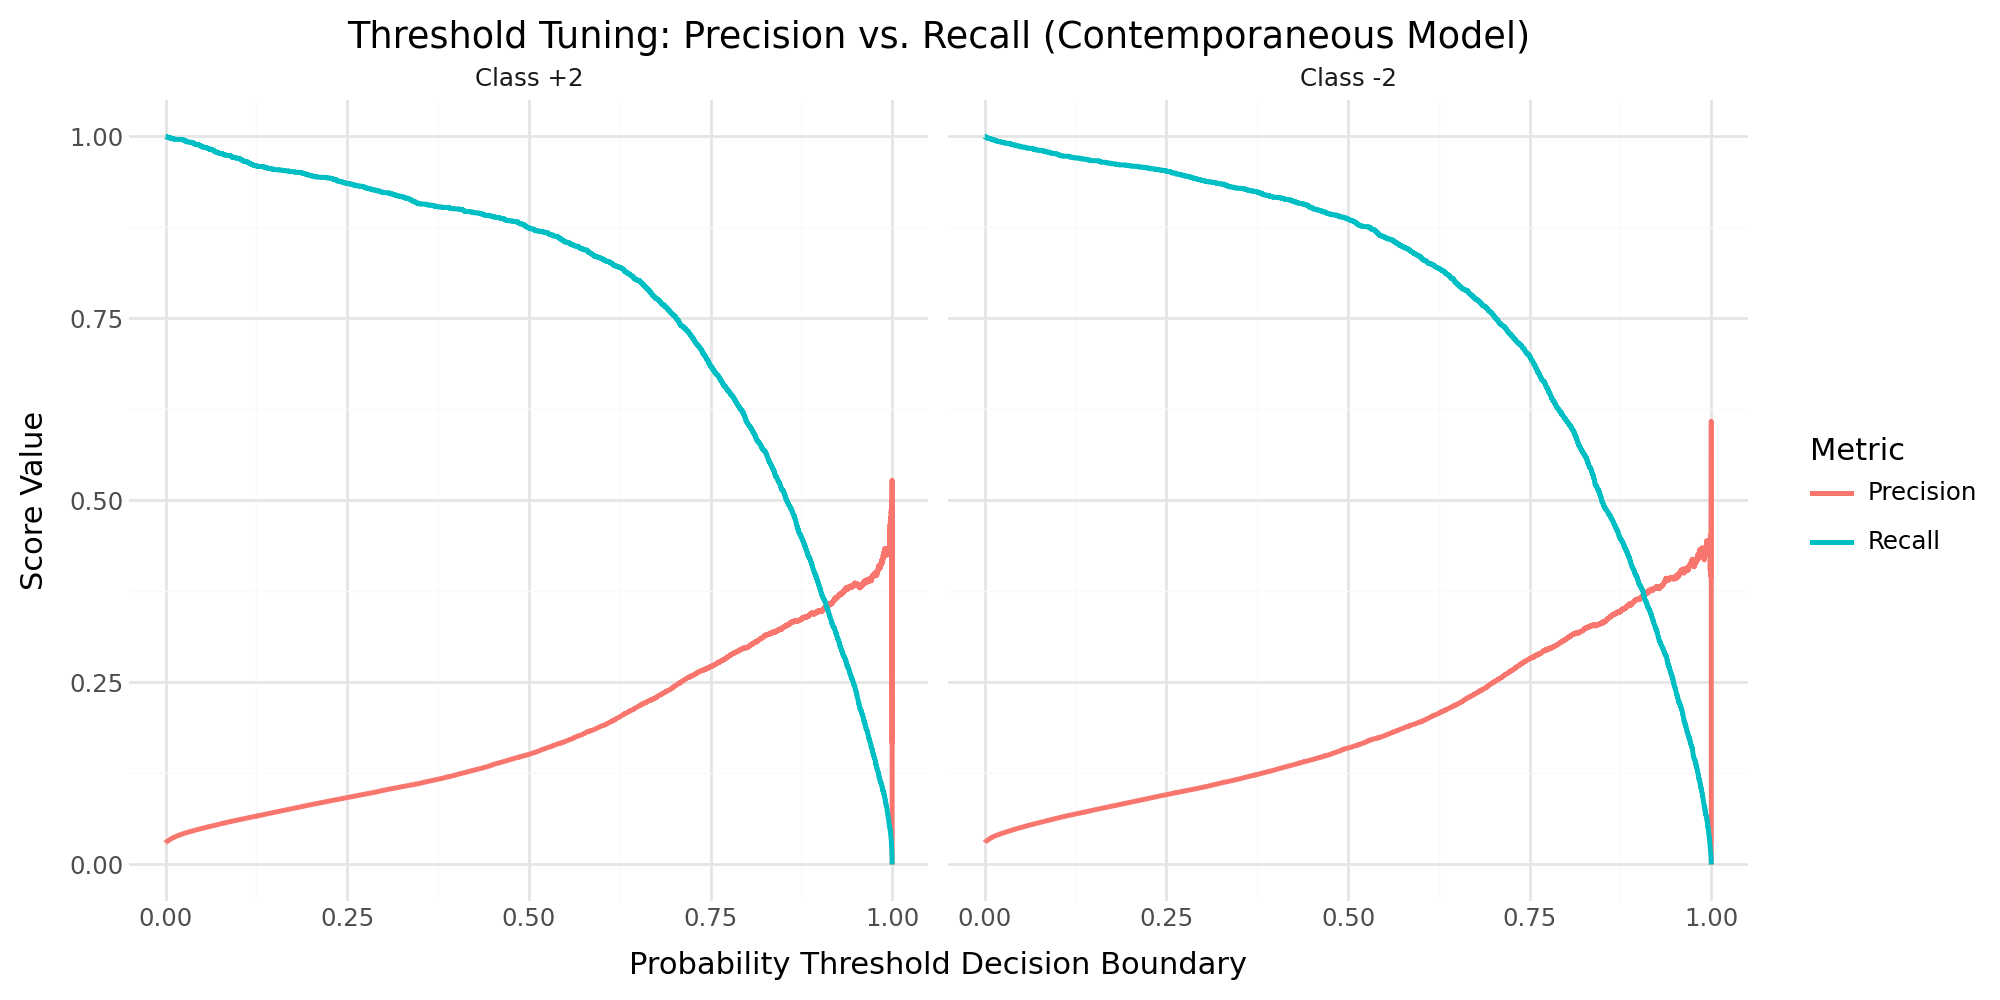

In [106]:
# --- 9b  Confusion matrix -------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve

CATS = [-2, 0, 2]

# In-sample predicted class = category with highest predicted probability
pred_probs = np.asarray(result_olr.predict())          # (n, 3)
true_classes = olr_df['delta_p'].astype(int).values

y_true_neg2 = (true_classes == -2).astype(int)
y_true_pos2 = (true_classes == 2).astype(int)

# 2. Extract the raw predicted probabilities for each tail class
prob_neg2 = pred_probs[:, 0]
prob_pos2 = pred_probs[:, 2]

# 3. Compute precision-recall pairs for different probability thresholds
prec_neg2, rec_neg2, thresh_neg2 = precision_recall_curve(y_true_neg2, prob_neg2)
prec_pos2, rec_pos2, thresh_pos2 = precision_recall_curve(y_true_pos2, prob_pos2)

# 4. Construct DataFrames 
# (Note: sklearn's precision/recall arrays are 1 element longer than thresholds; 
# we truncate the last element with [:-1] to align them perfectly)
df_neg2 = pd.DataFrame({
    'Threshold': thresh_neg2,
    'Precision': prec_neg2[:-1],
    'Recall': rec_neg2[:-1],
    'Class': 'Class -2'
})

df_pos2 = pd.DataFrame({
    'Threshold': thresh_pos2,
    'Precision': prec_pos2[:-1],
    'Recall': rec_pos2[:-1],
    'Class': 'Class +2'
})

# 5. Combine and reshape to long format for plotnine
df_tuning = pd.concat([df_neg2, df_pos2], ignore_index=True)
df_tuning_long = df_tuning.melt(
    id_vars=['Threshold', 'Class'], 
    value_vars=['Precision', 'Recall'], 
    var_name='Metric', 
    value_name='Value'
)

# 6. Plot Precision & Recall vs Threshold using plotnine
(
    ggplot(df_tuning_long, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title='Threshold Tuning: Precision vs. Recall (Contemporaneous Model)',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric'
    )
    + theme(figure_size=(10, 5))
)


In-sample accuracy: 0.8734

              precision    recall  f1-score   support

          -2       0.28      0.70      0.40      3238
           0       0.98      0.89      0.93    100825
          +2       0.27      0.68      0.39      3195

    accuracy                           0.87    107258
   macro avg       0.51      0.76      0.57    107258
weighted avg       0.94      0.87      0.90    107258



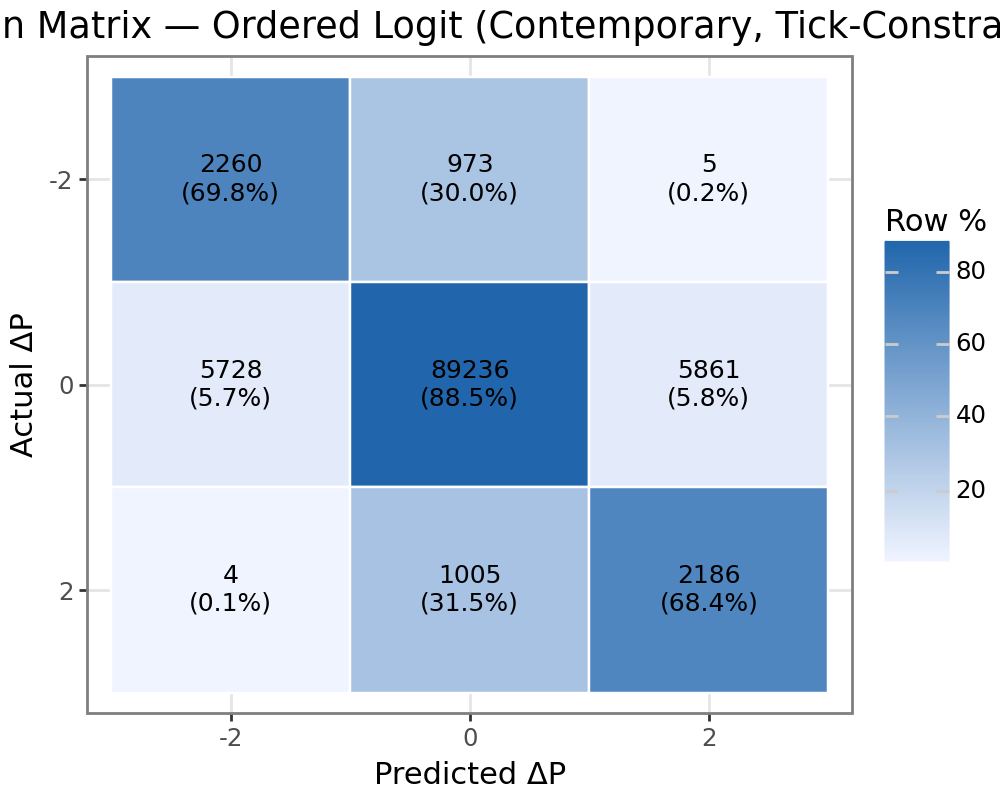

In [107]:
# Tidy confusion-matrix DataFrame
PROB_THRESH = 0.75   # default threshold for class assignment (can be tuned based on the above plot)

pred_classes = np.where(pred_probs[:, 2] >= PROB_THRESH, 2,   # predict +2 if prob ≥ threshold
                np.where(pred_probs[:, 0] >= PROB_THRESH, -2,  # else predict -2 if prob ≥ threshold
                         0))  # else predict 0 (majority class)

acc = (pred_classes == true_classes).mean()
print(f'In-sample accuracy: {acc:.4f}\n')
print(classification_report(true_classes, pred_classes, target_names=['-2', '0', '+2']))

cm = confusion_matrix(true_classes, pred_classes, labels=CATS)
cm_long = (
    pd.DataFrame(cm, index=CATS, columns=CATS)
    .rename_axis('Actual').reset_index()
    .melt(id_vars='Actual', var_name='Predicted', value_name='n')
    .assign(
        row_pct=lambda d: 100 * d['n'] / d.groupby('Actual')['n'].transform('sum'),
        label=lambda d: d.apply(
            lambda r: f"{int(r['n'])}\n({r['row_pct']:.1f}%)", axis=1
        ),
    )
)
# Ordered factors: x = -2 -> 0 -> 2; y reversed so -2 sits at top
for col, order in [('Predicted', ['-2', '0', '2']), ('Actual', ['2', '0', '-2'])]:
    cm_long[col] = pd.Categorical(cm_long[col].astype(str), categories=order)

(
    ggplot(cm_long, aes(x='Predicted', y='Actual', fill='row_pct')) +
    geom_tile(color='white', size=0.5) +
    geom_text(aes(label='label'), size=9) +
    scale_fill_gradient(low='#f0f4ff', high='#2166ac', name='Row %') +
    labs(
        title='Confusion Matrix — Ordered Logit (Contemporary, Tick-Constrained)',
        x='Predicted ΔP', y='Actual ΔP',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(5, 4))
)

## 10  Predictive Model: Ordered Logistic Regression (1-Step-Ahead)

Identical architecture to §9, but the target is $\Delta P_{t+1}$ — the next bin's
price change shifted into the current row via `.shift(-1).over(['security', 'date'])`.
No forward-looking leakage: the shift is partitioned by `[security, date]`.

In [108]:
# --- 10a  Build forward target and fit predictive ordered logit ---------------
# delta_p_fwd_t = delta_p_{t+1}: bring the next bin's price change into the
# current row. The last bin of every session has no forward value → null → dropped.
pred_df = (
    df_signals_tc_clean
    .sort(['security', 'date', 'bin_start_time'])
    .with_columns(
        delta_p_fwd=pl.col('delta_p').shift(-1).over(['security', 'date'])
    )
    .drop_nulls(subset=['delta_p_fwd'])
    .select(['delta_p_fwd', 'obi', 'ofi', 'stv', 'noi'])
    .drop_nulls()
    .to_pandas()
)
# Strictly ordered categories: -2 < 0 < 2
pred_df['delta_p_fwd'] = pd.Categorical(
    pred_df['delta_p_fwd'].astype(int),
    categories=[-2, 0, 2],
    ordered=True,
)

print(f'Observations: {len(pred_df):,}')
print(pred_df['delta_p_fwd'].value_counts().sort_index())

# Class weights: 30× for ±2 (minority), 1× for 0 (majority)
obs_weights_fwd = np.where(
    pred_df['delta_p_fwd'].astype(int).values == 0, 1.0, CLASS_WEIGHT_MINOR
)

model_olr_fwd = WeightedOrderedModel(
    pred_df['delta_p_fwd'],
    pred_df[['obi', 'noi', 'stv']],
    obs_weights=obs_weights_fwd,
    distr='logit',
)
result_olr_fwd = model_olr_fwd.fit(
    method='bfgs',
    cov_type='HAC',
    cov_kwds={'maxlags': HAC_LAGS},
    disp=False,
)
print(result_olr_fwd.summary())

Observations: 106,227
delta_p_fwd
-2     3190
 0    99880
 2     3157
Name: count, dtype: int64
                          WeightedOrderedModel Results                          
Dep. Variable:              delta_p_fwd   Log-Likelihood:            -1.9960e+05
Model:             WeightedOrderedModel   AIC:                         3.992e+05
Method:              Maximum Likelihood   BIC:                         3.993e+05
Date:                  Wed, 10 Jun 2026                                         
Time:                          11:04:30                                         
No. Observations:                106227                                         
Df Residuals:                    106222                                         
Df Model:                             3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
obi            2.

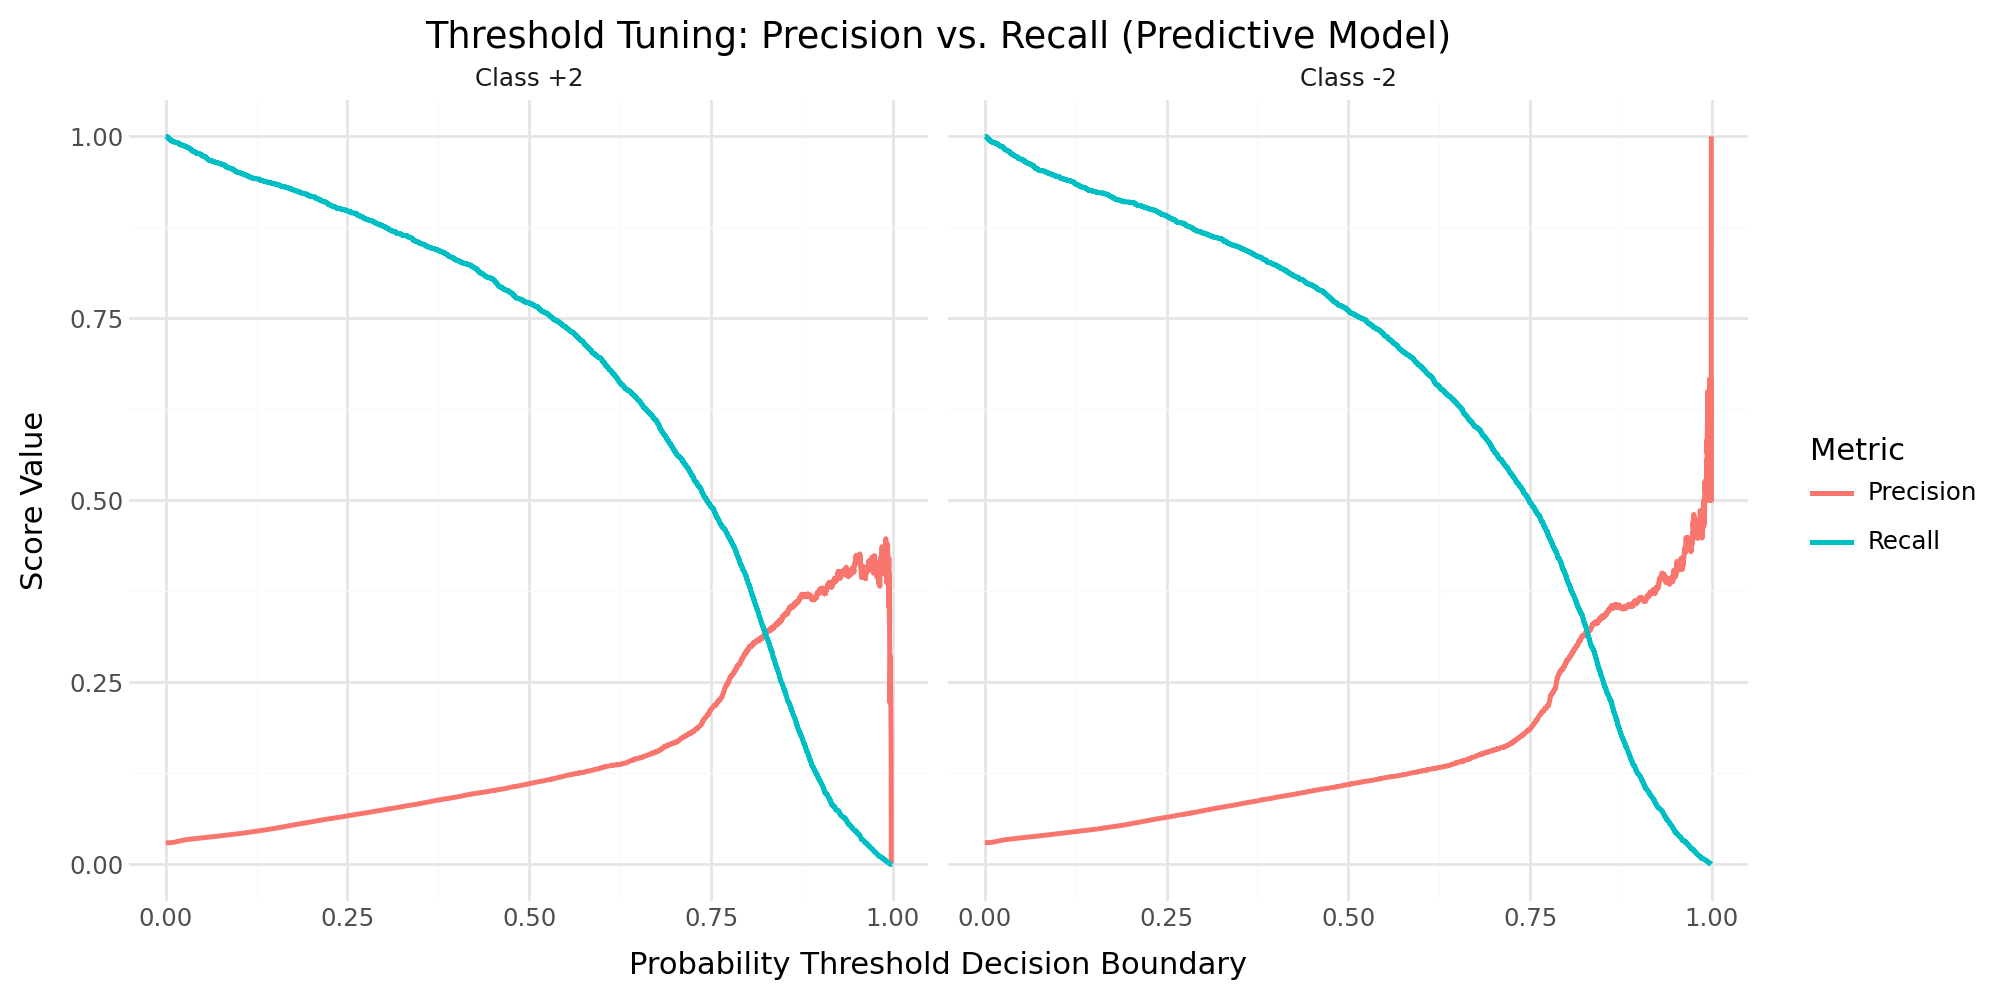

In [109]:
# --- 10b  Confusion matrix (predictive model) ---------------------------------
from sklearn.metrics import confusion_matrix, classification_report

CATS = [-2, 0, 2]

pred_probs_fwd  = np.asarray(result_olr_fwd.predict())        # (n, 3)
true_classes_fwd = pred_df['delta_p_fwd'].astype(int).values

y_true_neg2_fwd = (true_classes_fwd == -2).astype(int)
y_true_pos2_fwd = (true_classes_fwd == 2).astype(int)

prob_neg2_fwd = pred_probs_fwd[:, 0]
prob_pos2_fwd = pred_probs_fwd[:, 2]

prec_neg2_fwd, rec_neg2_fwd, thresh_neg2_fwd = precision_recall_curve(y_true_neg2_fwd, prob_neg2_fwd)
prec_pos2_fwd, rec_pos2_fwd, thresh_pos2_fwd = precision_recall_curve(y_true_pos2_fwd, prob_pos2_fwd)

df_neg2_fwd = pd.DataFrame({
    'Threshold': thresh_neg2_fwd,
    'Precision': prec_neg2_fwd[:-1],
    'Recall': rec_neg2_fwd[:-1],
    'Class': 'Class -2'
})

df_pos2_fwd = pd.DataFrame({
    'Threshold': thresh_pos2_fwd,
    'Precision': prec_pos2_fwd[:-1],
    'Recall': rec_pos2_fwd[:-1],
    'Class': 'Class +2'
})

df_tuning_fwd = pd.concat([df_neg2_fwd, df_pos2_fwd], ignore_index=True)
df_tuning_long_fwd = df_tuning_fwd.melt(
    id_vars=['Threshold', 'Class'],
    value_vars=['Precision', 'Recall'],
    var_name='Metric',
    value_name='Value'
)

(
    ggplot(df_tuning_long_fwd, aes(x='Threshold', y='Value', color='Metric'))
    + geom_line(size=1)
    + facet_wrap('~Class', scales='free_x')
    + theme_minimal()
    + labs(
        title='Threshold Tuning: Precision vs. Recall (Predictive Model)',
        x='Probability Threshold Decision Boundary',
        y='Score Value',
        color='Metric'
    )
    + theme(figure_size=(10, 5))
)

In-sample accuracy: 0.9057

              precision    recall  f1-score   support

          -2       0.28      0.39      0.33      3190
           0       0.96      0.94      0.95     99880
          +2       0.29      0.39      0.34      3157

    accuracy                           0.91    106227
   macro avg       0.51      0.57      0.54    106227
weighted avg       0.92      0.91      0.91    106227



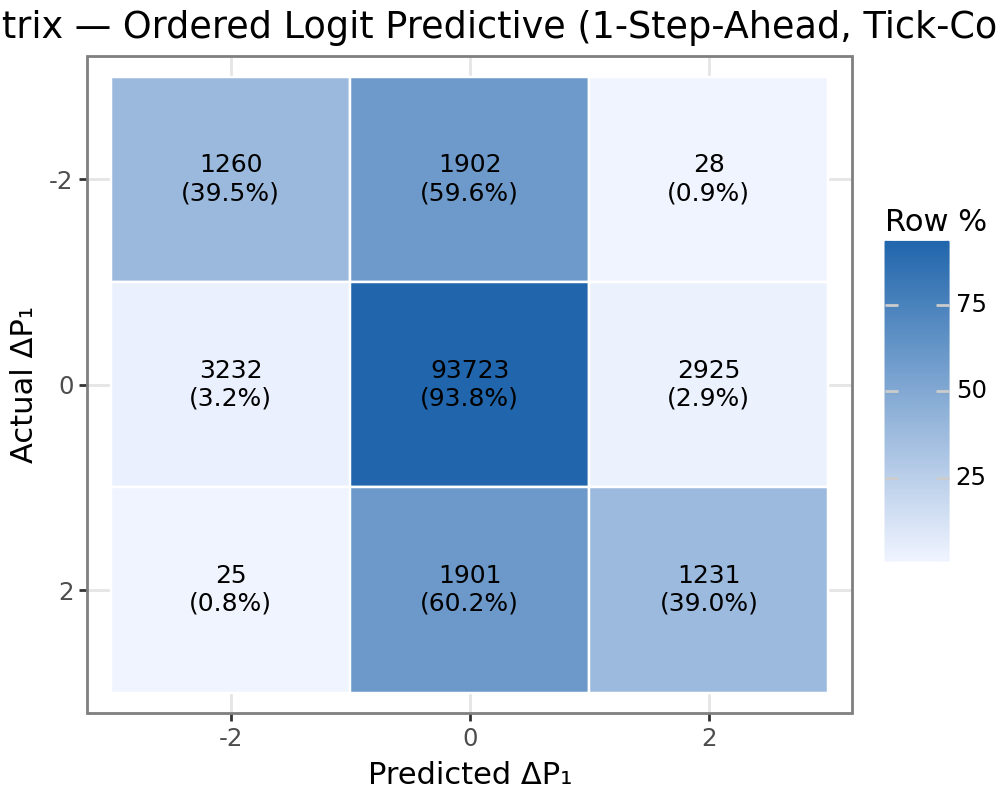

In [110]:
THRESH_FWD = 0.8   # default threshold for class assignment (can be tuned based on the precision-recall curves)

pred_classes_fwd = np.where(pred_probs_fwd[:, 2] >= THRESH_FWD, 2,   # predict +2 if prob ≥ threshold
                        np.where(pred_probs_fwd[:, 0] >= THRESH_FWD, -2,  # else predict -2 if prob ≥ threshold
                                 0))  # else predict 0 (majority class)

acc_fwd = (pred_classes_fwd == true_classes_fwd).mean()
print(f'In-sample accuracy: {acc_fwd:.4f}\n')
print(classification_report(true_classes_fwd, pred_classes_fwd, target_names=['-2', '0', '+2']))

cm_fwd = confusion_matrix(true_classes_fwd, pred_classes_fwd, labels=CATS)
cm_fwd_long = (
    pd.DataFrame(cm_fwd, index=CATS, columns=CATS)
    .rename_axis('Actual').reset_index()
    .melt(id_vars='Actual', var_name='Predicted', value_name='n')
    .assign(
        row_pct=lambda d: 100 * d['n'] / d.groupby('Actual')['n'].transform('sum'),
        label=lambda d: d.apply(
            lambda r: f"{int(r['n'])}\n({r['row_pct']:.1f}%)", axis=1
        ),
    )
)
for col, order in [('Predicted', ['-2', '0', '2']), ('Actual', ['2', '0', '-2'])]:
    cm_fwd_long[col] = pd.Categorical(cm_fwd_long[col].astype(str), categories=order)

(
    ggplot(cm_fwd_long, aes(x='Predicted', y='Actual', fill='row_pct')) +
    geom_tile(color='white', size=0.5) +
    geom_text(aes(label='label'), size=9) +
    scale_fill_gradient(low='#f0f4ff', high='#2166ac', name='Row %') +
    labs(
        title='Confusion Matrix — Ordered Logit Predictive (1-Step-Ahead, Tick-Constrained)',
        x='Predicted ΔP₁', y='Actual ΔP₁',
    ) +
    theme_bw(base_size=11) +
    theme(figure_size=(5, 4))
)